# **training an MLP model on the CIFAR-10 dataset**

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision

## MLP class definition:

In [3]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(3072, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 10)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    return x

## DataLoader:

In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader

def get_dataloaders(batch_size=64):
    transform = transforms.ToTensor()

    train_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader

# training for one batch (64 images)
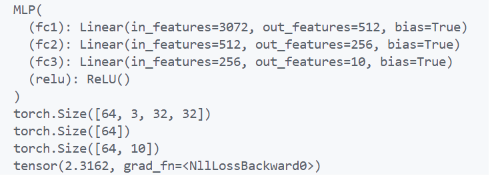

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()
outputs = model(images)
print(outputs.shape)

loss = criterion(outputs, labels)
print(loss)

loss.backward()
optimizer.step()

## output:
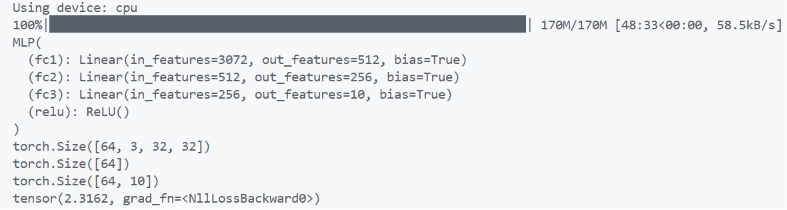
<br>
- dataset downloaded as this was the first time dataLoader was called

# training for one epoch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

num_epochs = 1
for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        # print(images.shape)
        # print(labels.shape)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        # print(outputs.shape)

        loss = criterion(outputs, labels)
        # print(loss)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )    

## output:
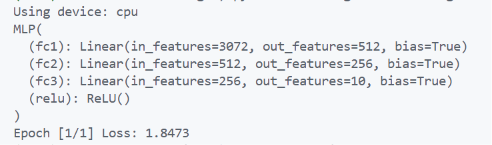
<br>
- ran the model for one epoch twice before this output, which is why the loss seems so less

# training for  multiple epochs

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        # print(images.shape)
        # print(labels.shape)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        # print(outputs.shape)

        loss = criterion(outputs, labels)
        # print(loss)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )    

## output:
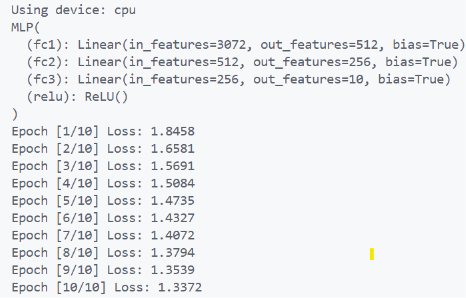

# training for one epoch again, but also added accuracy score

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

num_epochs = 1
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # print(images.shape)
        # print(labels.shape)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        # print(outputs.shape)

        loss = criterion(outputs, labels)
        # print(loss)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
        f"Accuracy: {accuracy:.2f}%"
    )    

## output:
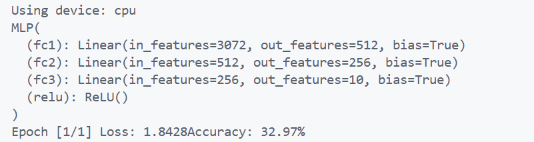
<br>
- forgot space before Accuracy ;(

# saving model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

num_epochs = 1
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # print(images.shape)
        # print(labels.shape)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        # print(outputs.shape)

        loss = criterion(outputs, labels)
        # print(loss)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )  
# print(model.state_dict())
torch.save(
    model.state_dict(),
    "saved_models/mlp.pth"
)  
print("Model saved to saved_models/mlp.pth")

## output:
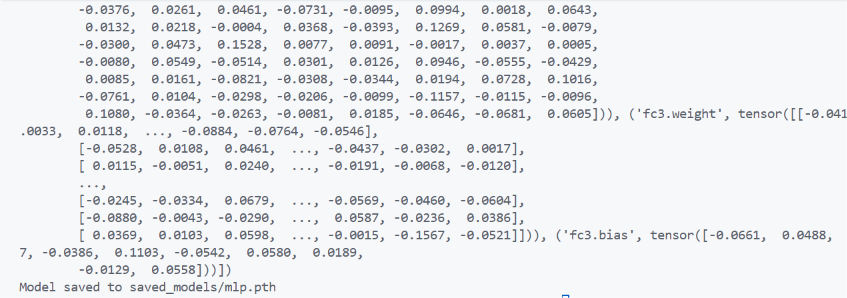
<br>
- even though it is commented in the code above, i tried printing model.stat_dict() and as you can see it gave a really fun output lol

# evaluating model

In [ ]:
import torch

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

_, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
model.load_state_dict(
    torch.load("saved_models/mlp.pth", map_location=device)
)
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

## output: 
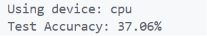
<br>
- basically just loads the model, gets test dataset, makes prediction, computes test accuracy, nothing is learned in this

# adding everything together, so model gets trained, evaluated, saved, all in one script

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

best_accuracy = 0.0
num_epochs = 10
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #evaluate
    model.eval()

    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, dim=1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * test_correct / test_total

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        torch.save(
            model.state_dict(),
            "saved_models/mlp.pth"
        ) 
        print("Model saved to saved_models/mlp.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Test Acc: {test_accuracy:.2f}%"
    )  

print(f"Best Test Accuracy: {best_accuracy:.2f}%")

## output:
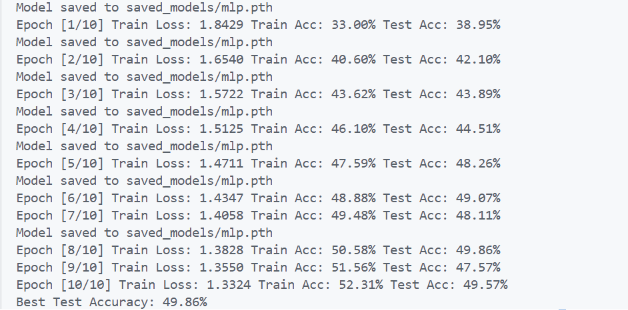
<br>
- overfitting can be observed, as training accuracy keeps increasing, and test accuracy slows down and even drops 

# visualization of the loss curve and accuracy curve

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

train_losses = []
train_accuracies = []
test_accuracies = []

best_accuracy = 0.0
num_epochs = 10
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #evaluate
    model.eval()

    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, dim=1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * test_correct / test_total

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        torch.save(
            model.state_dict(),
            "saved_models/mlp.pth"
        ) 
        print("Model saved to saved_models/mlp.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Test Acc: {test_accuracy:.2f}%"
    )  

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

print(f"Best Test Accuracy: {best_accuracy:.2f}%")

epochs = range(1, num_epochs + 1)

# plot for loss curve
plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# plot for accuracy curve
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(epochs, test_accuracies, marker="o", label="Test Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

## output:
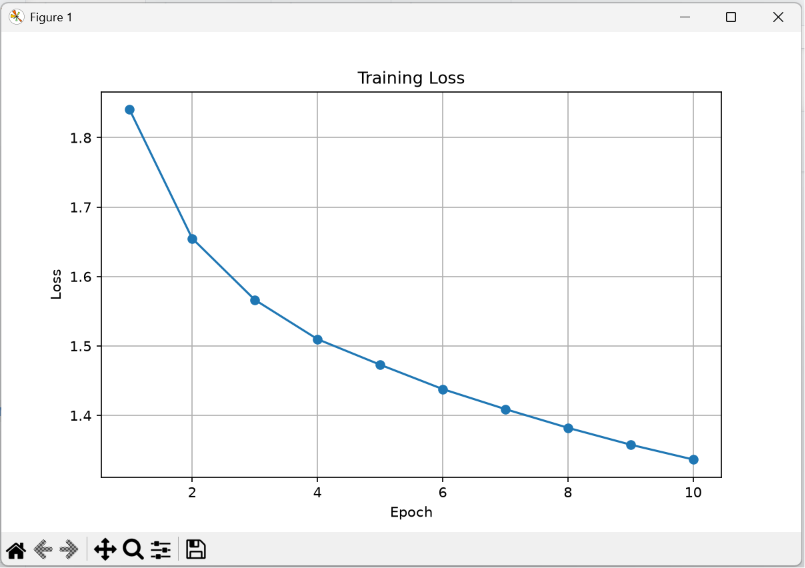
<br><br>
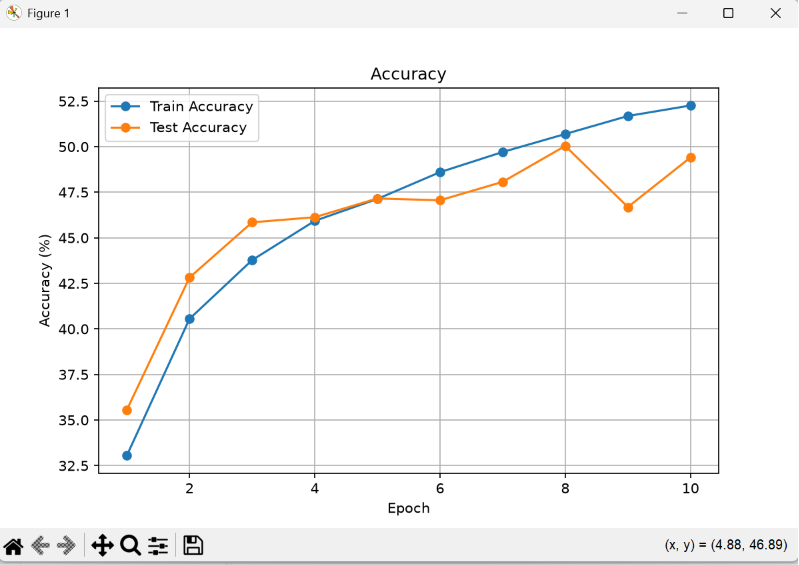
<br><br>

- Epoch 1–5, Both curves increase together
- Epoch 5–8, Training accuracy continues increasing, Test accuracy also improves
- Epoch 9,  first sign of overfitting, model becomes better on training data but worse on unseen data
- Epoch 10, test accuracy recovers to around 49.5%, means that the previous drop may have been due to randomness, or  test set being small
- Overall, overfitting is mild rather than severe
- Possible underfitting as both train and test accuracy are only around 50%
- after CNN, we will do more visualization like: Confusion Matrix, Sample Predictions, CNN vs MLP Comparision, Optimizer, Comparision, Learning Rate Comparison, Data Augmentation Comparison, Transfer Learning Comparison

## output: (30 epochs)
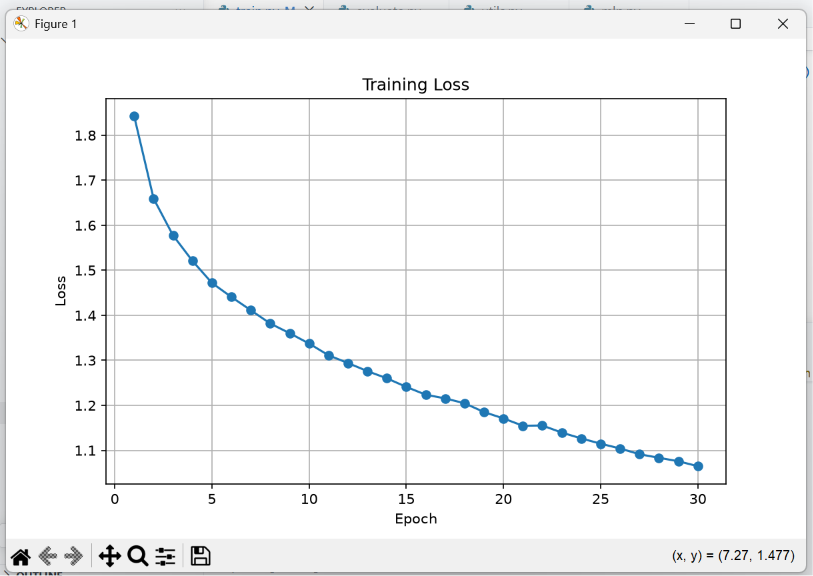
<br><br>
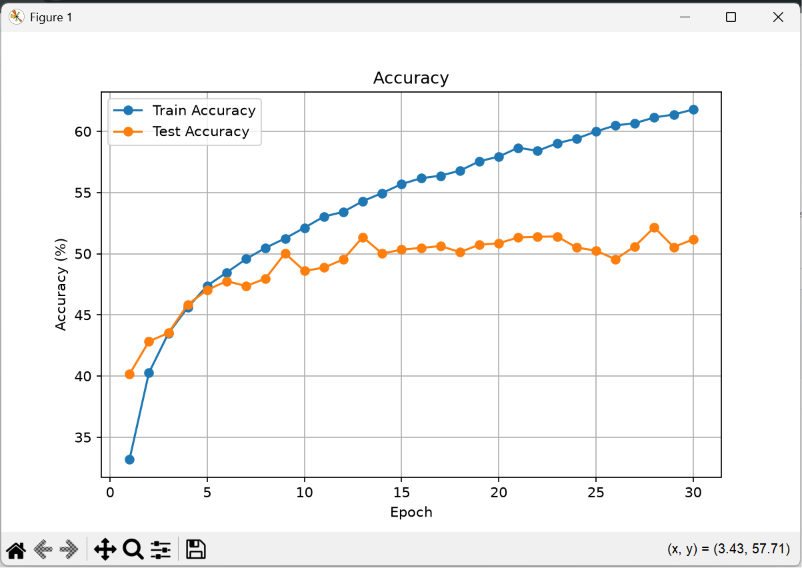
<br>